In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

%matplotlib inline

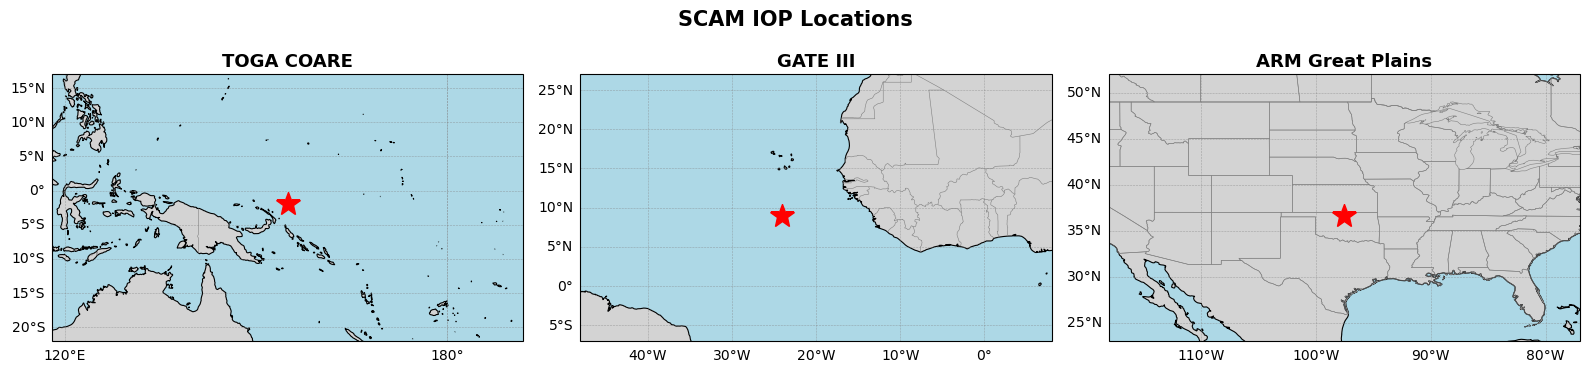

Saved: iop_locations.png


In [8]:
# ── IOP sites (lat/lon read from *_4scam.nc files) ────────────────────
# Per-site projection centred on site longitude — keeps TOGA COARE's
# domain away from the dateline. set_aspect('auto') forces equal panel sizes.
geo = ccrs.PlateCarree()

sites = [
    {'name': 'TOGA COARE',
     'lat':  -2.0,  'lon': 155.0,
     'extent': [118, 192, -22, 17],
     'proj': ccrs.PlateCarree(central_longitude=155)},
    {'name': 'GATE III',
     'lat':   9.0,  'lon': -24.0,
     'extent': [-48, 8, -7, 27],
     'proj': ccrs.PlateCarree(central_longitude=-24)},
    {'name': 'ARM Great Plains',
     'lat':  36.61, 'lon': -97.49,
     'extent': [-118, -77, 23, 52],
     'proj': ccrs.PlateCarree(central_longitude=-97)},
]

fig = plt.figure(figsize=(16, 3.75))

for i, site in enumerate(sites):
    ax = fig.add_subplot(1, 3, i + 1, projection=site['proj'])
    ax.set_extent(site['extent'], crs=geo)
    ax.set_aspect('auto')   # override cartopy aspect so all panels fill equal space

    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.OCEAN,     facecolor='lightblue', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8,          zorder=1)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor='gray', zorder=1)
    if 'ARM' in site['name']:
        ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='gray', zorder=1)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray',
                      alpha=0.6, linestyle='--', x_inline=False, y_inline=False)
    gl.top_labels   = False
    gl.right_labels = False

    ax.plot(site['lon'], site['lat'], marker='*', color='red', markersize=18,
            transform=geo, zorder=5)
    ax.set_title(site['name'], fontsize=13, fontweight='bold', pad=6)

fig.suptitle('SCAM IOP Locations', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('iop_locations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: iop_locations.png')